# Mixture table validation

Visual checks for the exported fixed-composition mixture tables and the
`TabularMixtureWrapper` built on top of them. The validation notebook requires
a REFPROP license

1. **State diagrams** computed with REFPROP: log(p)-h, T-s and the p-T phase
   envelope of the mixture.
2. **Wrapper deviations**: probe points evaluated through the
   `TabularMixtureWrapper` (cubic splines) against REFPROP.

In [1]:
import json

import CoolProp as CP
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

from tabular_mixture_wrapper import TabularMixtureWrapper
from tespy.tools.fluid_properties.wrappers import CoolPropWrapper

PATH = "tables/Isopentane_Isobutane_mass_0.50_0.50.npz"

data = np.load(PATH)
meta = json.loads(str(data["metadata"]))
wrapper = TabularMixtureWrapper("mixture", path=PATH)
ref = CoolPropWrapper("Isopentane[0.5]&Isobutane[0.5]|mass", "REFPROP")

COLOR_BUBBLE = "#1f77b4"
COLOR_DEW = "#ff7f0e"
COLOR_ISOLINE = "#999999"
CMAP_DEV = "Blues"

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

meta

{'fluid': 'Isopentane&Isobutane',
 'back_end': 'REFPROP',
 'mixture_type': 'mass',
 'fractions': [0.5, 0.5],
 'molar_mass': 0.06438035272193392,
 'T_crit': 435.2667930959034,
 'p_crit': 3737558.2264881493,
 'T_min': 253.15,
 'T_max': 485.2667930959034,
 'p_min': 24882.868876079887,
 'p_sat_max': 3626270.5615153513,
 'p_max': 7475116.4529762985,
 'units': 'SI (K, Pa, J/kg, J/kgK, kg/m3)',
 'coolprop_version': '8.0.0',
 'refprop_version': '10.0',
 'failed_points': 0,
 'filled_points': 0}

## REFPROP state diagrams

The saturation lines come from the exported arrays (exact REFPROP flash
results at the grid nodes); isolines are computed with REFPROP directly.
The temperature glide of the zeotropic mixture shows as the gap between
bubble and dew line in the p-T envelope and as sloped isobars inside the
dome of the T-s diagram.

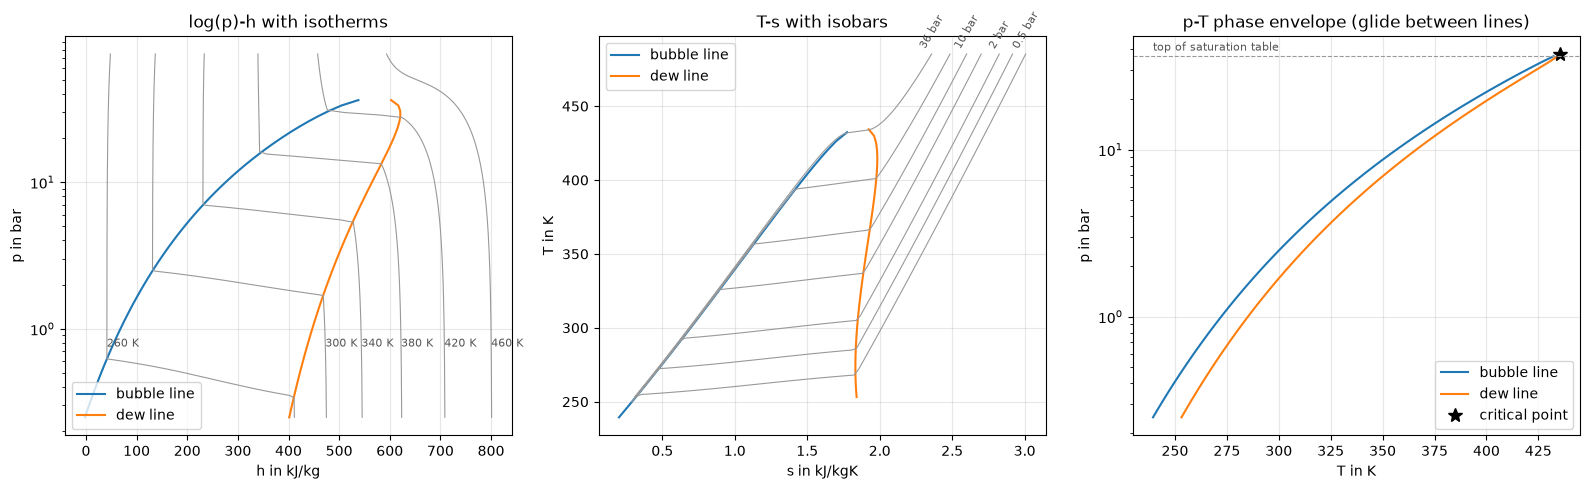

In [2]:
def ref_ph(p, h):
    ref.AS.update(CP.HmassP_INPUTS, h, p)
    return ref.AS.T(), ref.AS.smass(), ref.AS.rhomass()


p_sat = data["p"]

fig, (ax_ph, ax_ts, ax_pt) = plt.subplots(1, 3, figsize=(16, 5))

ax_ph.plot(data["sat_h_bubble"] / 1e3, p_sat / 1e5, color=COLOR_BUBBLE, label="bubble line")
ax_ph.plot(data["sat_h_dew"] / 1e3, p_sat / 1e5, color=COLOR_DEW, label="dew line")
for T in [260, 300, 340, 380, 420, 460]:
    p_iso = np.geomspace(meta["p_min"], meta["p_max"], 150)
    h_iso = np.full_like(p_iso, np.nan)
    for k, p in enumerate(p_iso):
        try:
            h_iso[k] = ref.h_pT(p, T)
        except ValueError:
            pass
    ax_ph.plot(h_iso / 1e3, p_iso / 1e5, color=COLOR_ISOLINE, lw=0.8)
    if np.isfinite(h_iso).any():
        k = np.nanargmin(np.abs(p_iso - meta["p_min"] * 3))
        ax_ph.annotate(f"{T} K", (h_iso[k] / 1e3, p_iso[k] / 1e5), fontsize=8, color="#555555")
ax_ph.set_yscale("log")
ax_ph.set_xlabel("h in kJ/kg")
ax_ph.set_ylabel("p in bar")
ax_ph.set_title("log(p)-h with isotherms")
ax_ph.legend()

ax_ts.plot(data["sat_s_bubble"] / 1e3, data["sat_T_bubble"], color=COLOR_BUBBLE, label="bubble line")
ax_ts.plot(data["sat_s_dew"] / 1e3, data["sat_T_dew"], color=COLOR_DEW, label="dew line")
for p in np.array([0.5, 1, 2, 5, 10, 20, 36]) * 1e5:
    h_lo, h_hi = wrapper._h_bounds(p)
    T_iso, s_iso = [], []
    for h in np.linspace(h_lo, h_hi, 100):
        try:
            T, s, _ = ref_ph(p, h)
        except ValueError:
            T, s = np.nan, np.nan
        T_iso += [T]
        s_iso += [s]
    ax_ts.plot(np.array(s_iso) / 1e3, T_iso, color=COLOR_ISOLINE, lw=0.8)
    if p / 1e5 in [0.5, 2, 10, 36]:
        ax_ts.annotate(f"{p / 1e5:g} bar", (s_iso[-1] / 1e3, T_iso[-1] + 4), fontsize=8, color="#555555", rotation=60, ha="center")
ax_ts.set_xlabel("s in kJ/kgK")
ax_ts.set_ylabel("T in K")
ax_ts.set_title("T-s with isobars")
ax_ts.legend()

ax_pt.plot(data["sat_T_bubble"], p_sat / 1e5, color=COLOR_BUBBLE, label="bubble line")
ax_pt.plot(data["sat_T_dew"], p_sat / 1e5, color=COLOR_DEW, label="dew line")
ax_pt.plot(meta["T_crit"], meta["p_crit"] / 1e5, "k*", ms=10, label="critical point")
ax_pt.axhline(meta["p_sat_max"] / 1e5, color="#999999", lw=0.8, ls="--")
ax_pt.annotate("top of saturation table", (data["sat_T_bubble"][0], meta["p_sat_max"] / 1e5 * 1.08), fontsize=8, color="#555555")
ax_pt.set_yscale("log")
ax_pt.set_xlabel("T in K")
ax_pt.set_ylabel("p in bar")
ax_pt.set_title("p-T phase envelope (glide between lines)")
ax_pt.legend()

fig.tight_layout()

## Probe points: cell midpoints of every table

Each record holds the REFPROP reference values and the bilinear interpolation
of the raw table arrays at the midpoint of every grid cell (density
interpolated as specific volume). Midpoints maximize the distance to the
nodes, so this is the worst case for the tabulated data.

In [3]:
def probe_block(records, region, p_arr, sigma_arr, h_lo_arr, h_hi_arr, tables):
    logp = np.log(p_arr)
    n_p, n_h = tables["T"].shape
    for i in range(n_p - 1):
        p = np.exp(0.5 * (logp[i] + logp[i + 1]))
        h_lo = 0.5 * (h_lo_arr[i] + h_lo_arr[i + 1])
        h_hi = 0.5 * (h_hi_arr[i] + h_hi_arr[i + 1])
        for j in range(n_h - 1):
            sg = 0.5 * (sigma_arr[j] + sigma_arr[j + 1])
            h = h_lo + sg * (h_hi - h_lo)
            try:
                T_r, s_r, d_r = ref_ph(p, h)
            except ValueError:
                continue
            records += [{
                "region": region, "p": p, "h": h,
                "T_ref": T_r, "s_ref": s_r, "d_ref": d_r,
                # tabular midpoint interpolation as extra outputs
                "T_tab": tables["T"][i:i + 2, j:j + 2].mean(),
                "s_tab": tables["s"][i:i + 2, j:j + 2].mean(),
                "d_tab": 1 / (1 / tables["d"][i:i + 2, j:j + 2]).mean(),
            }]


records = []
region_edges = {
    "liquid": ("sat_h_liquid_min", "sat_h_bubble"),
    "twophase": ("sat_h_bubble", "sat_h_dew"),
    "vapor": ("sat_h_dew", "sat_h_vapor_max"),
}
for region, (lo, hi) in region_edges.items():
    tables = {key: data[f"{region}_{key}"] for key in ["T", "s", "d"]}
    probe_block(records, region, data["p"], data["sigma"], data[lo], data[hi], tables)

sc_tables = {key: data[f"sc_{key}"] for key in ["T", "s", "d"]}
probe_block(records, "supercritical", data["sc_p"], data["sc_sigma"], data["sc_h_min"], data["sc_h_max"], sc_tables)

df = pd.DataFrame(records)

df["T_wrap"] = [wrapper.T_ph(p, h) for p, h in zip(df["p"], df["h"])]
df["s_wrap"] = [wrapper.s_ph(p, h) for p, h in zip(df["p"], df["h"])]
df["d_wrap"] = [wrapper.d_ph(p, h) for p, h in zip(df["p"], df["h"])]

for src in ["tab", "wrap"]:
    df[f"dT_{src}"] = (df[f"T_{src}"] - df["T_ref"]).abs()
    df[f"ds_{src}"] = (df[f"s_{src}"] - df["s_ref"]).abs()
    df[f"dd_{src}"] = (df[f"d_{src}"] - df["d_ref"]).abs() / df["d_ref"] * 100

print(f"{len(df)} probe points")
df.head()

def zone_summary(df, src):
    """p99 and max deviation per zone; overall row on top."""
    scopes = {"overall": df}
    scopes.update({
        region: df[df["region"] == region]
        for region in ["liquid", "twophase", "vapor", "supercritical"]
    })
    out = {}
    for scope, subset in scopes.items():
        row = {"n": len(subset)}
        for col, label in [
            (f"dT_{src}", "dT_K"), (f"ds_{src}", "ds_JkgK"), (f"dd_{src}", "dd_pct")
        ]:
            row[f"{label}_p99"] = subset[col].quantile(0.99)
            row[f"{label}_max"] = subset[col].max()
        out[scope] = row
    return pd.DataFrame(out).T.round(4)


9204 probe points


In [4]:
def deviation_panels(df, src, title):
    specs = [
        (f"dT_{src}", "|dT| in K"),
        (f"ds_{src}", "|ds| in J/kgK"),
        (f"dd_{src}", "|dd|/d in %"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
    for ax, (col, label) in zip(axes, specs):
        dev = df[col].clip(lower=df[col][df[col] > 0].min())
        sc = ax.scatter(
            df["h"] / 1e3, df["p"] / 1e5, c=dev, s=3, cmap=CMAP_DEV,
            norm=LogNorm(vmin=dev.quantile(0.05), vmax=dev.max())
        )
        ax.plot(data["sat_h_bubble"] / 1e3, data["p"] / 1e5, color="#333333", lw=0.8)
        ax.plot(data["sat_h_dew"] / 1e3, data["p"] / 1e5, color="#333333", lw=0.8)
        ax.set_yscale("log")
        ax.set_xlabel("h in kJ/kg")
        fig.colorbar(sc, ax=ax, label=label)
    axes[0].set_ylabel("p in bar")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

## Deviation of the wrapper (cubic splines) vs REFPROP

Same probe points, evaluated through `TabularMixtureWrapper.T_ph`, `s_ph` and
`d_ph`.

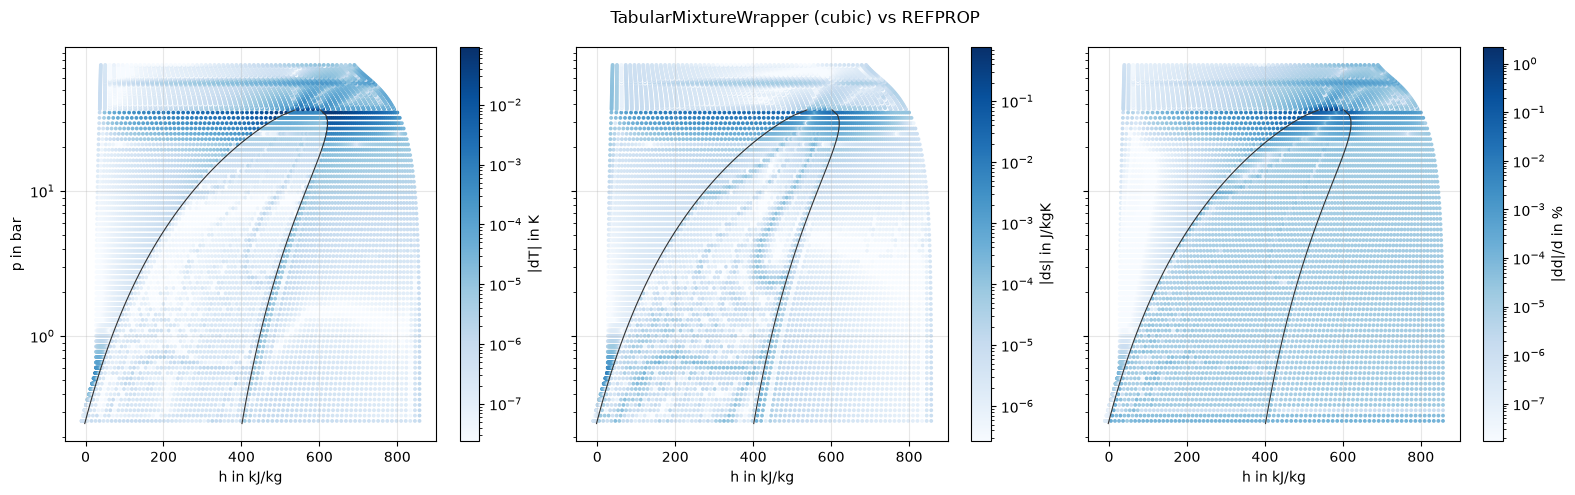

In [5]:
fig = deviation_panels(df, "wrap", "TabularMixtureWrapper (cubic) vs REFPROP")

In [6]:
zone_summary(df, "wrap")

,n,dT_K_p99,dT_K_max,ds_JkgK_p99,ds_JkgK_max,dd_pct_p99,dd_pct_max
overall,9204.0,0.0045,0.0927,0.0083,0.7730,0.0130,2.2045
liquid,2301.0,0.0045,0.0927,0.0162,0.7730,0.0085,0.2518
twophase,2301.0,0.0006,0.0008,0.0100,0.0288,0.0324,0.1262
vapor,2301.0,0.0193,0.0583,0.0038,0.0225,0.0022,0.0999
supercritical,2301.0,0.0006,0.0753,0.0001,0.0087,0.0056,2.2045


## Deviation histograms

Distribution of all probe-point deviations on logarithmic bins.


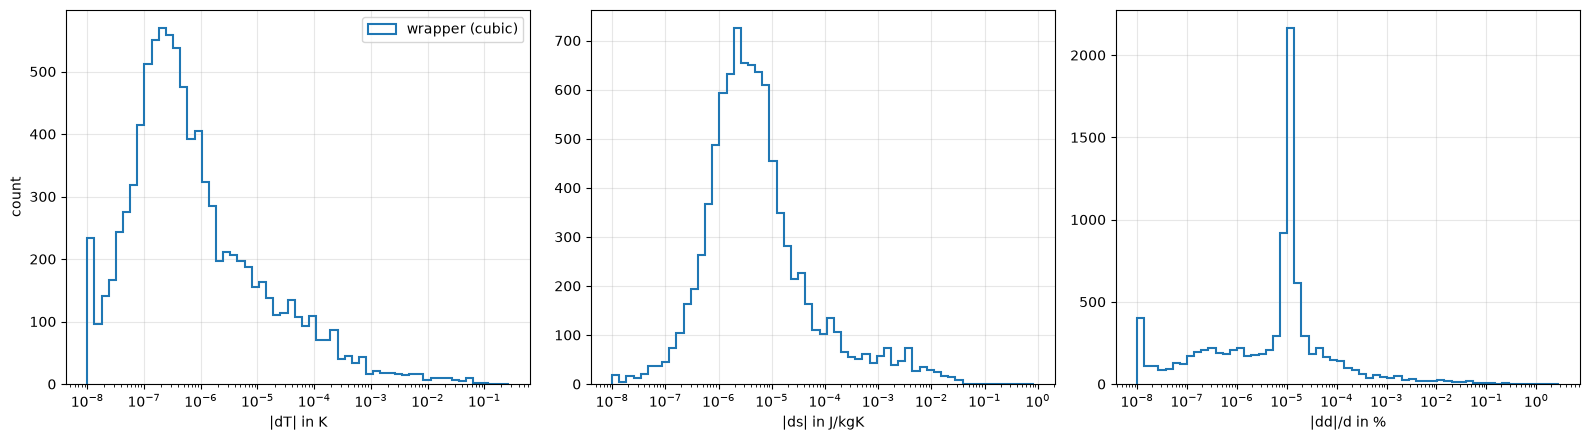

In [7]:
FLOOR = 1e-8
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
specs = [("dT", "|dT| in K"), ("ds", "|ds| in J/kgK"), ("dd", "|dd|/d in %")]
for ax, (col, label) in zip(axes, specs):
    hi = max(df[f"{col}_tab"].max(), df[f"{col}_wrap"].max()) * 1.1
    bins = np.geomspace(FLOOR, hi, 60)
    for src, color, name in [
        # ("tab", "#999999", "raw tables (bilinear)"),
        ("wrap", "#1f77b4", "wrapper (cubic)"),
    ]:
        ax.hist(
            df[f"{col}_{src}"].clip(lower=FLOOR), bins=bins,
            histtype="step", lw=1.5, color=color, label=name
        )
    ax.set_xscale("log")
    ax.set_xlabel(label)
axes[0].set_ylabel("count")
axes[0].legend()
fig.tight_layout()